In [1]:
import pandas as pd


In [2]:
from pathlib import Path

In [3]:
# 1. Load data
file_path = "HR_capstone_dataset.csv"   # change if your file name is different
df = pd.read_csv(file_path)

# Quick look
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


In [4]:
# 2. Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Optional: fix common typo if present
df = df.rename(columns={"average_montly_hours": "average_monthly_hours"})

df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [5]:
# 3. Missing values
df.isna().sum()

# 3.1 Drop exact duplicate rows (if any)
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 3008
Duplicates after: 0


In [6]:
# 4. Data types
df.dtypes

# 4.1 Basic range checks
print(df[["satisfaction_level", "last_evaluation"]].describe())
print(df[["number_project", "average_monthly_hours", "time_spend_company"]].describe())

# 4.2 Check binary columns for unexpected values
for col in ["work_accident", "left", "promotion_last_5years"]:
    print(col, sorted(df[col].unique()))

       satisfaction_level  last_evaluation
count        11991.000000     11991.000000
mean             0.629658         0.716683
std              0.241070         0.168343
min              0.090000         0.360000
25%              0.480000         0.570000
50%              0.660000         0.720000
75%              0.820000         0.860000
max              1.000000         1.000000
       number_project  average_monthly_hours  time_spend_company
count    11991.000000           11991.000000        11991.000000
mean         3.802852             200.473522            3.364857
std          1.163238              48.727813            1.330240
min          2.000000              96.000000            2.000000
25%          3.000000             157.000000            3.000000
50%          4.000000             200.000000            3.000000
75%          5.000000             243.000000            4.000000
max          7.000000             310.000000           10.000000
work_accident [np.int64(0), 

In [7]:
# Example: remove rows with impossible satisfaction values
df = df[(df["satisfaction_level"] >= 0) & (df["satisfaction_level"] <= 1)]

In [9]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

In [10]:
# 5. Clean categorical columns

if "department" in df.columns:
    df["department"] = df["department"].astype(str).str.strip().str.lower()

if "salary" in df.columns:
    df["salary"] = df["salary"].astype(str).str.strip().str.lower()

# Check unique values
print("Departments:", df["department"].unique())
print("Salary:", df["salary"].unique())

Departments: ['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'it'
 'product_mng' 'marketing' 'randd']
Salary: ['low' 'medium' 'high']


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [12]:
df.info()
df.describe()
df["left"].value_counts(normalize=True) * 100  # attrition rate in %

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


left
0    83.39588
1    16.60412
Name: proportion, dtype: float64

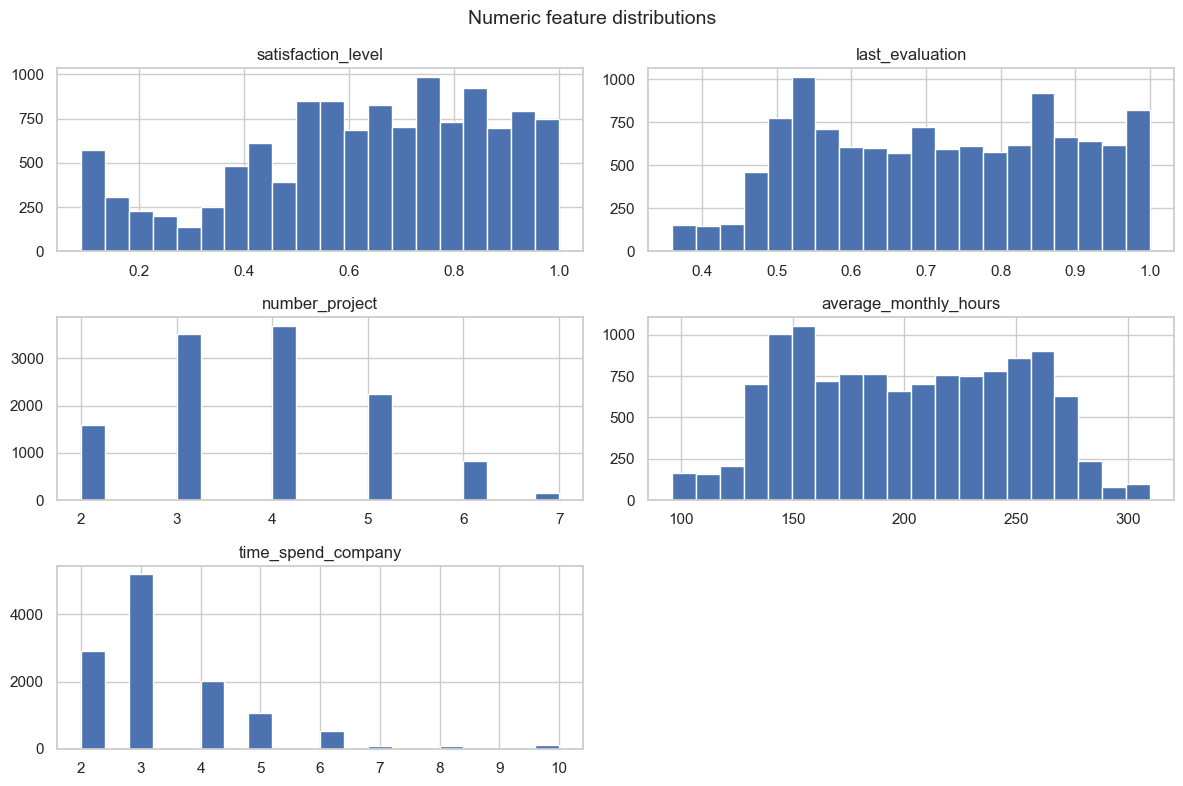

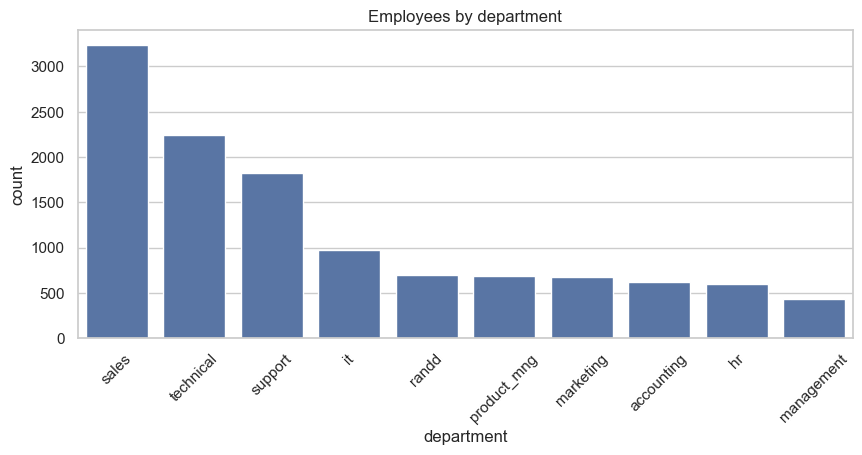

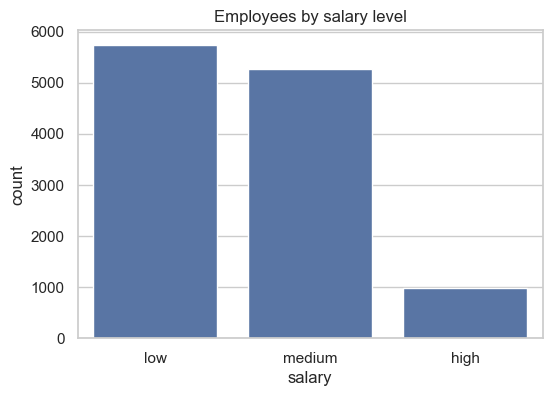

In [13]:
# Numeric distributions
num_cols = ["satisfaction_level", "last_evaluation", "number_project",
            "average_monthly_hours", "time_spend_company"]

df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Numeric feature distributions", fontsize=14)
plt.tight_layout()
plt.show()

# Categorical distributions
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Employees by department")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="salary", order=["low", "medium", "high"])
plt.title("Employees by salary level")
plt.show()

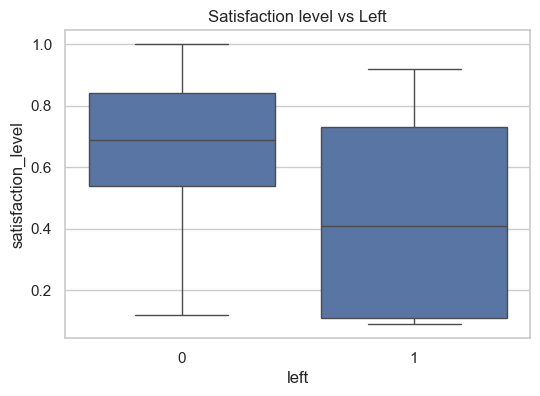

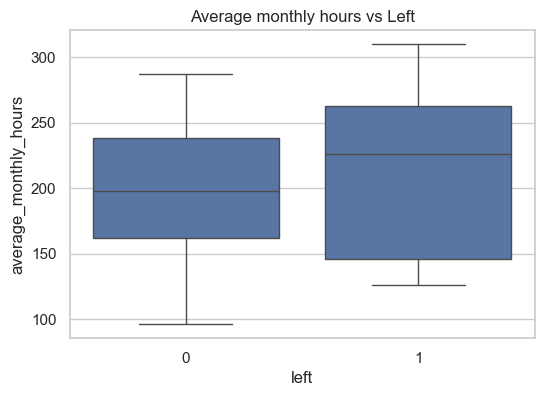

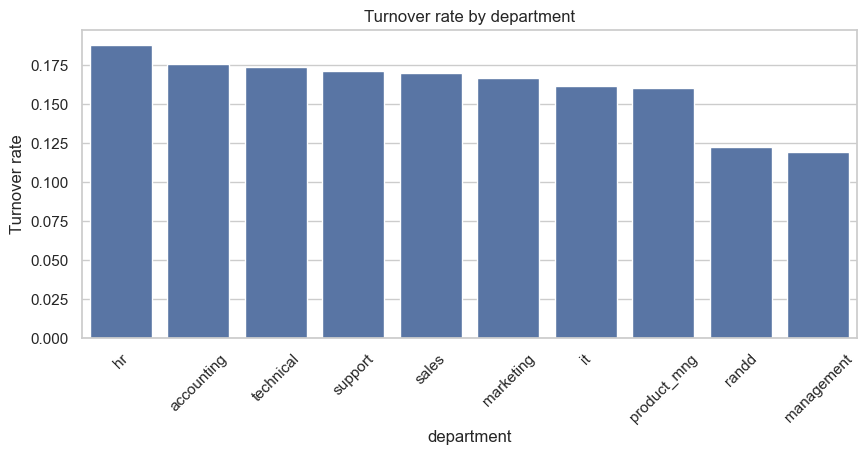

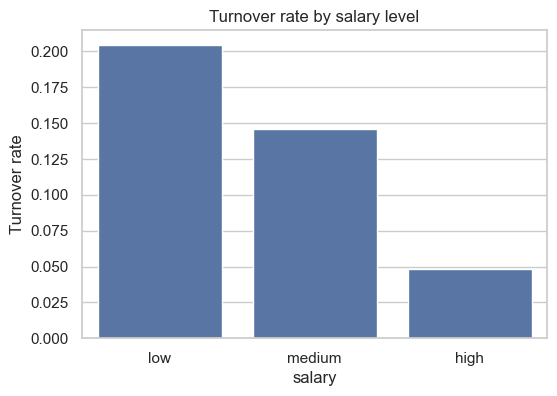

In [14]:
# Satisfaction vs attrition
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="left", y="satisfaction_level")
plt.title("Satisfaction level vs Left")
plt.show()

# Monthly hours vs attrition
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="left", y="average_monthly_hours")
plt.title("Average monthly hours vs Left")
plt.show()

# Turnover rate by department
dept_turnover = df.groupby("department")["left"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,4))
sns.barplot(x=dept_turnover.index, y=dept_turnover.values)
plt.xticks(rotation=45)
plt.ylabel("Turnover rate")
plt.title("Turnover rate by department")
plt.show()

# Turnover rate by salary
salary_turnover = df.groupby("salary")["left"].mean().reindex(["low","medium","high"])

plt.figure(figsize=(6,4))
sns.barplot(x=salary_turnover.index, y=salary_turnover.values)
plt.ylabel("Turnover rate")
plt.title("Turnover rate by salary level")
plt.show()

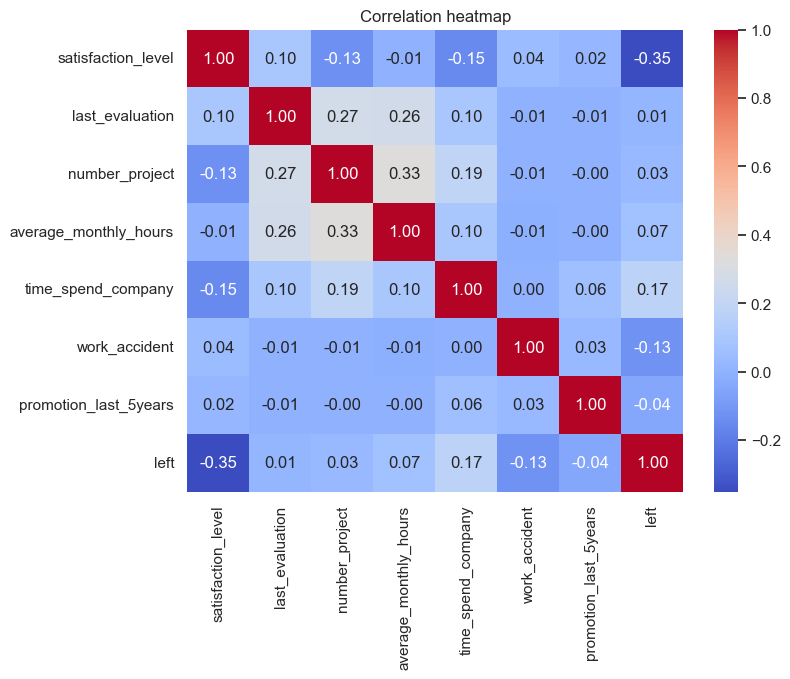

In [15]:
plt.figure(figsize=(8,6))
corr = df[["satisfaction_level", "last_evaluation", "number_project",
           "average_monthly_hours", "time_spend_company",
           "work_accident", "promotion_last_5years", "left"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Features and target
X = df.drop("left", axis=1)
y = df["left"]

# Identify column types
numeric_features = ["satisfaction_level", "last_evaluation", "number_project",
                    "average_monthly_hours", "time_spend_company",
                    "work_accident", "promotion_last_5years"]

categorical_features = ["department", "salary"]

# Preprocess: one‑hot encode categoricals, pass through numeric as is
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# Train‑test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [17]:
log_reg = LogisticRegression(max_iter=1000)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", log_reg)
])

clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8345563709139426

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      2500
           1       0.50      0.21      0.29       498

    accuracy                           0.83      2998
   macro avg       0.68      0.58      0.60      2998
weighted avg       0.80      0.83      0.80      2998


Confusion matrix:
 [[2399  101]
 [ 395  103]]


In [19]:
import numpy as np

# Get the names of the one‑hot encoded columns
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

coefs = clf.named_steps["model"].coef_[0]
feature_importance = sorted(
    zip(all_feature_names, coefs),
    key=lambda x: abs(x[1]),
    reverse=True
)

for name, coef in feature_importance[:15]:
    print(f"{name:30s} {coef:.3f}")

satisfaction_level             -3.869
salary_low                     1.874
salary_medium                  1.468
work_accident                  -1.376
promotion_last_5years          -0.959
last_evaluation                0.595
department_randd               -0.474
department_management          -0.320
time_spend_company             0.314
number_project                 -0.283
department_product_mng         -0.097
department_technical           0.059
department_hr                  0.047
department_it                  -0.035
department_support             -0.035


In [20]:
df_proba = df.copy()
df_proba["leave_proba"] = clf.predict_proba(df.drop("left", axis=1))[:, 1]
df_proba.sort_values("leave_proba", ascending=False).head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary,leave_proba
11297,0.14,0.58,4,275,10,0,0,0,sales,medium,0.904976
11195,0.47,0.79,3,284,10,0,0,0,sales,low,0.861460
9416,0.13,0.62,3,264,6,0,0,0,accounting,low,0.842060
11011,0.21,0.70,3,238,8,0,0,0,technical,medium,0.830184
9417,0.14,0.89,3,212,6,0,0,0,accounting,low,0.829591


In [22]:
# 6. Save cleaned data
df.to_csv("HR_clean.csv", index=False)
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
